In [13]:
import pandas as pd

data = pd.read_csv("../data/ai4i2020.csv")

data.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [14]:
# Remove unnecessary columns safely
data = data.drop(["UDI", "Product ID"], axis=1, errors="ignore")

# Remove failure indicator columns (prevent data leakage)
data = data.drop(["TWF","HDF","PWF","OSF","RNF"], axis=1, errors="ignore")

In [15]:
data = pd.get_dummies(data, columns=["Type"])

data.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Type_H,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,False,False,True
1,298.2,308.7,1408,46.3,3,0,False,True,False
2,298.1,308.5,1498,49.4,5,0,False,True,False
3,298.2,308.6,1433,39.5,7,0,False,True,False
4,298.2,308.7,1408,40.0,9,0,False,True,False


In [16]:
# Temperature difference
data["temp_diff"] = data["Process temperature [K]"] - data["Air temperature [K]"]

# Stress index
data["stress_index"] = data["Torque [Nm]"] * data["Rotational speed [rpm]"]

data.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Type_H,Type_L,Type_M,temp_diff,stress_index
0,298.1,308.6,1551,42.8,0,0,False,False,True,10.5,66382.8
1,298.2,308.7,1408,46.3,3,0,False,True,False,10.5,65190.4
2,298.1,308.5,1498,49.4,5,0,False,True,False,10.4,74001.2
3,298.2,308.6,1433,39.5,7,0,False,True,False,10.4,56603.5
4,298.2,308.7,1408,40.0,9,0,False,True,False,10.5,56320.0


In [17]:
# Features (input variables)
X = data.drop("Machine failure", axis=1)

# Target variable
y = data["Machine failure"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)


Feature shape: (10000, 10)
Target shape: (10000,)


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (8000, 10)
Testing data: (2000, 10)


In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete")

Scaling complete


In [20]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_scaled, y_train)

print("Logistic Regression trained")

Logistic Regression trained


In [21]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=6,
    random_state=42
)

dt_model.fit(X_train, y_train)

print("Decision Tree trained")

Decision Tree trained


In [22]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest trained")

Random Forest trained


In [23]:
from sklearn.metrics import accuracy_score

# Predictions
lr_pred = lr_model.predict(X_test_scaled)
dt_pred = dt_model.predict(X_test)
rf_pred = rf_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Logistic Regression Accuracy: 0.9675
Decision Tree Accuracy: 0.988
Random Forest Accuracy: 0.991


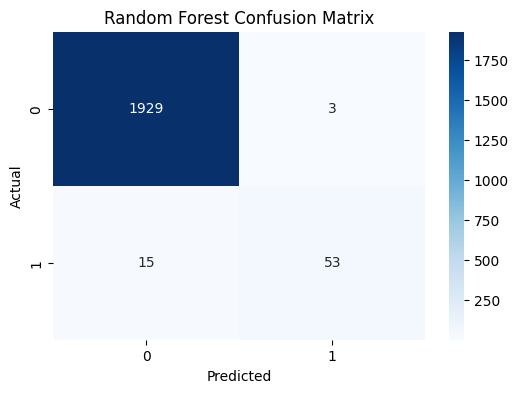

In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Save image
plt.savefig("../results/confusion_matrix.png")

plt.show()

In [25]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1932
           1       0.95      0.78      0.85        68

    accuracy                           0.99      2000
   macro avg       0.97      0.89      0.93      2000
weighted avg       0.99      0.99      0.99      2000



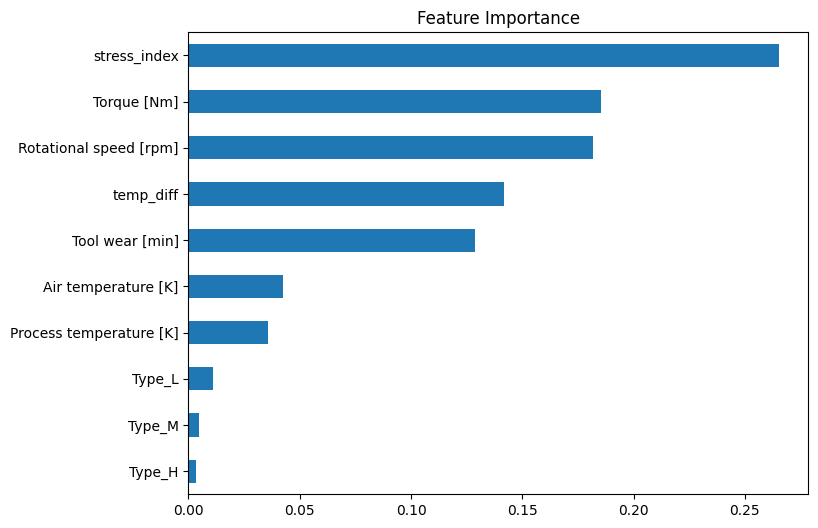

In [28]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)

plt.figure(figsize=(8,6))

feature_importance.sort_values().plot(kind="barh")

plt.title("Feature Importance")

plt.savefig("../results/feature_importance.png")

plt.show()

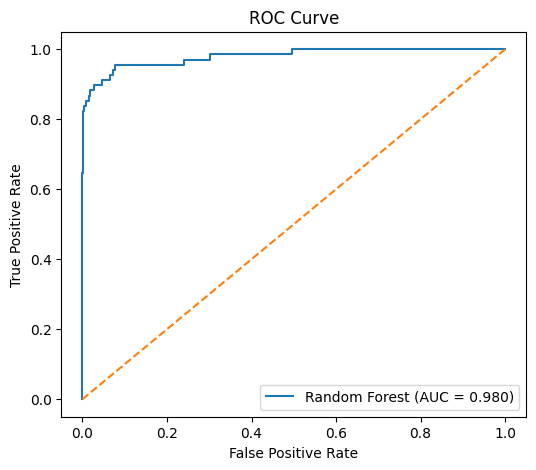

In [29]:
from sklearn.metrics import roc_curve, auc

rf_prob = rf_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, rf_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label="Random Forest (AUC = %0.3f)" % roc_auc)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.savefig("../results/roc_curve.png")

plt.show()

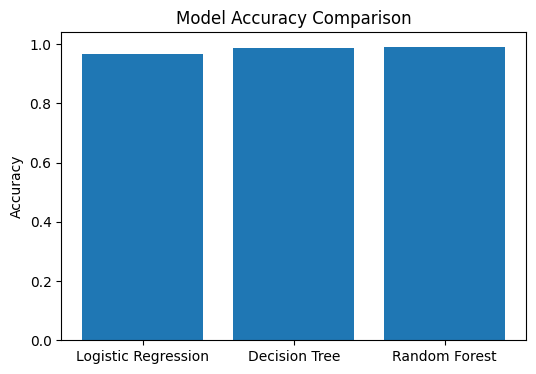

In [30]:
models = ["Logistic Regression", "Decision Tree", "Random Forest"]
accuracies = [0.9675, 0.988, 0.991]

plt.figure(figsize=(6,4))

plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.savefig("../results/model_accuracy.png")

plt.show()